In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import streamlit as st



In [3]:
df = pd.read_csv("satlog_data.csv")
df.head()

,carga_id,temperatura_carga,velocidade_media_kmh,distancia_destino_km,atraso_horas,status_rota,sinal_satelite,tipo_carga,risco
0,1,28,84,1375,11,Parado,Medio,Eletronico,Alto
1,2,18,40,774,4,Parado,Medio,Eletronico,Alto
2,3,21,46,1192,4,Desvio,Medio,Alimento,Medio
3,4,7,98,216,12,Normal,Fraco,Eletronico,Alto
4,5,-3,40,1190,9,Desvio,Medio,Alimento,Alto


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   carga_id              500 non-null    int64 
 1   temperatura_carga     500 non-null    int64 
 2   velocidade_media_kmh  500 non-null    int64 
 3   distancia_destino_km  500 non-null    int64 
 4   atraso_horas          500 non-null    int64 
 5   status_rota           500 non-null    object
 6   sinal_satelite        500 non-null    object
 7   tipo_carga            500 non-null    object
 8   risco                 500 non-null    object
dtypes: int64(5), object(4)
memory usage: 35.3+ KB


# VERIFICAÇÃO E LIMPEZA DE DADOS
aqui vamos verificar os dados para observar se eles possuem alguma incogruencia ou se ja podem ser usados para teste

numero de dados duplicados 0


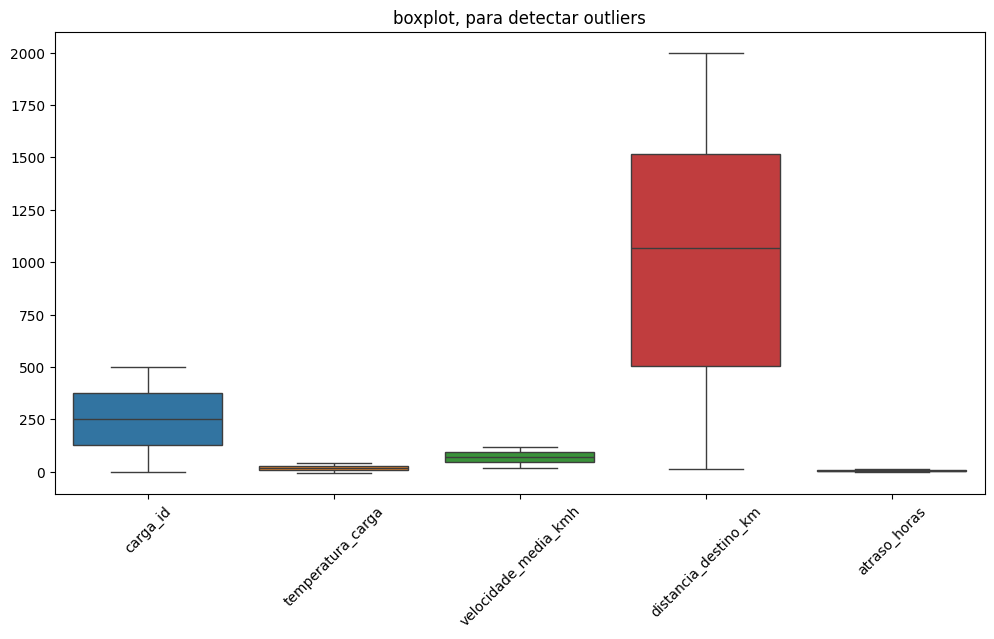

In [5]:
duplicates = df.duplicated().sum()
print("numero de dados duplicados", duplicates)
#primeiro é necessario verificar se existem duplicatas no code
#verificar a presença de outliers
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.title("boxplot, para detectar outliers")
plt.xticks(rotation=45)
plt.show()


O boxplot permitiu avaliar a dispersão dos dados e identificar possíveis outliers. A variável distancia_destino_km apresentou a maior variabilidade, enquanto temperatura_carga, velocidade_media_kmh e atraso_horas mostraram distribuições mais concentradas. Não foram observados outliers extremos que justificassem tratamento adicional, permitindo a continuidade da análise e modelagem dos dados.

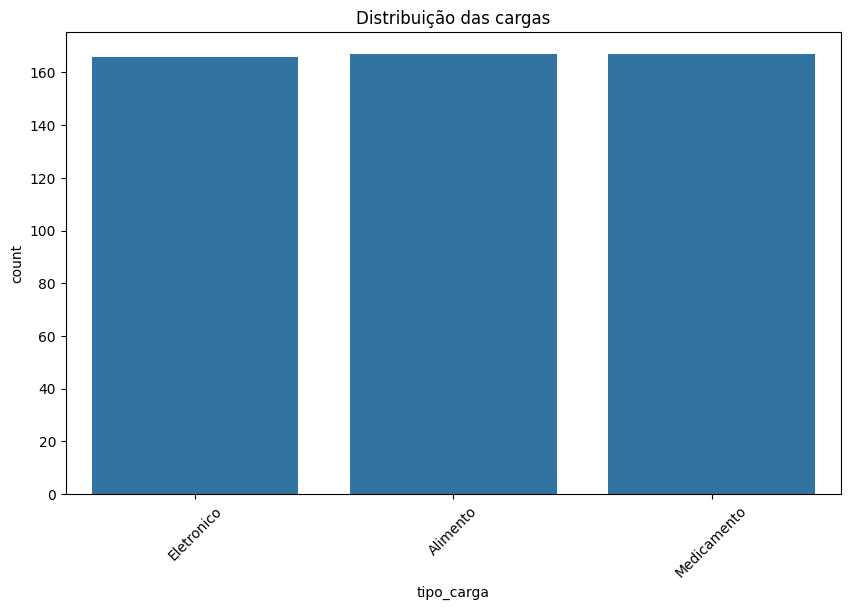

In [6]:
plt.figure(figsize=(10, 6))
sns.countplot(x='tipo_carga', data=df)
plt.title("Distribuição das cargas")
plt.xticks(rotation=45)
plt.show()

O gráfico apresenta a distribuição dos registros por tipo de carga transportada. Observa-se que as categorias Eletrônico, Alimento e Medicamento possuem quantidades muito semelhantes de registros, indicando uma base de dados balanceada em relação à variável tipo_carga. Esse equilíbrio é importante para o treinamento dos modelos de Machine Learning, pois reduz o risco de viés em favor de uma categoria específica e contribui para previsões mais consistentes e confiáveis. A distribuição uniforme também permite realizar comparações entre os diferentes tipos de carga sem que uma classe tenha influência desproporcional sobre os resultados.

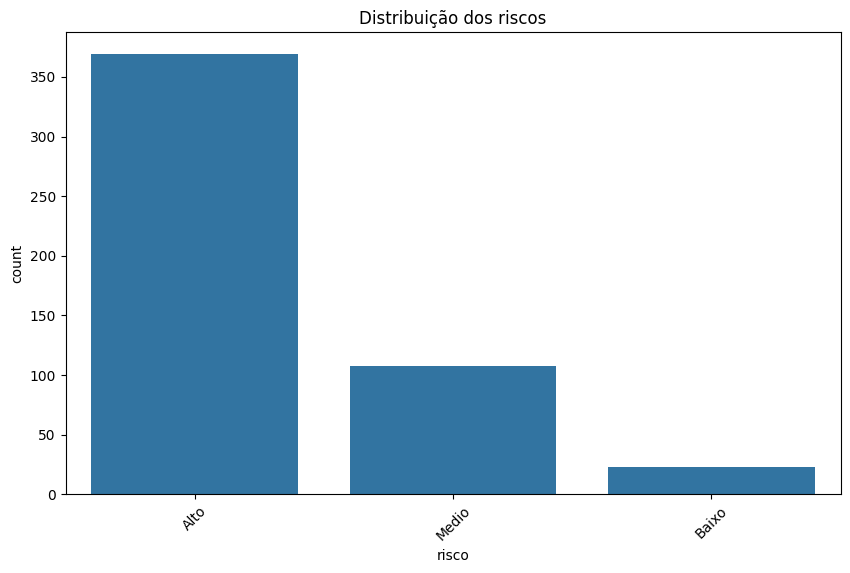

In [10]:
plt.figure(figsize=(10, 6))
sns.countplot(x='risco', data=df)
plt.title("Distribuição dos riscos")
plt.xticks(rotation=45)
plt.show()

O gráfico apresenta a distribuição dos registros de acordo com o nível de risco classificado na base de dados. Observa-se uma predominância significativa da categoria Alto, seguida pela categoria Médio, enquanto a categoria Baixo possui uma quantidade consideravelmente menor de registros. Essa distribuição indica um desbalanceamento entre as classes, característica importante a ser considerada durante o treinamento dos modelos de Machine Learning. Em cenários como esse, o modelo pode apresentar tendência a prever com maior frequência a classe majoritária, exigindo uma análise cuidadosa das métricas de desempenho além da acurácia, como precisão, recall e matriz de confusão. Apesar do desbalanceamento, a distribuição reflete um cenário realista de monitoramento logístico, no qual situações de maior risco podem ocorrer com maior frequência devido às condições operacionais simuladas.

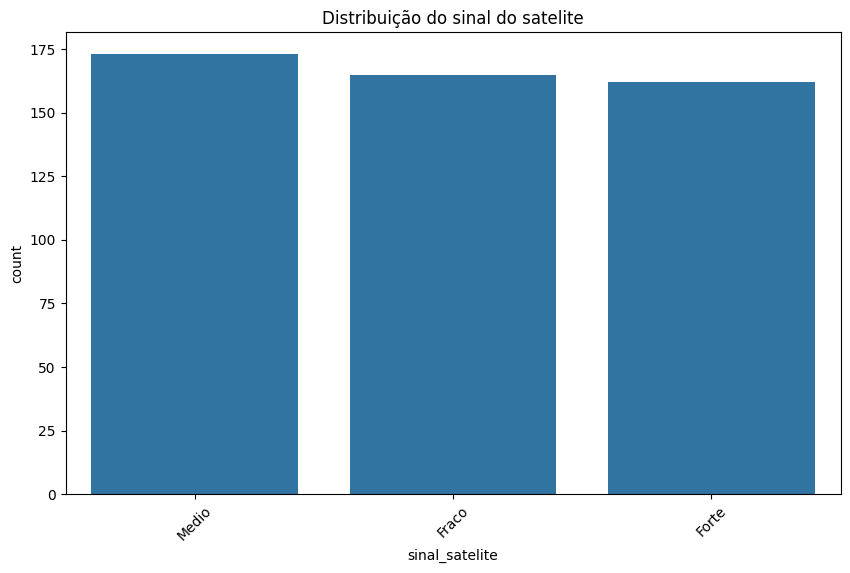

In [11]:
plt.figure(figsize=(10, 6))
sns.countplot(x='sinal_satelite', data=df)
plt.title("Distribuição do sinal do satelite")
plt.xticks(rotation=45)
plt.show()

O gráfico apresenta a distribuição dos registros de acordo com a qualidade do sinal de satélite durante o transporte das cargas. Observa-se que as categorias Médio, Fraco e Forte possuem quantidades bastante semelhantes de registros, demonstrando uma distribuição equilibrada dessa variável na base de dados. Esse balanceamento é importante para a modelagem preditiva, pois permite que o algoritmo aprenda padrões relacionados a todas as condições de sinal sem favorecer uma categoria específica. Além disso, a qualidade do sinal de satélite pode influenciar diretamente o monitoramento logístico, afetando a capacidade de rastreamento e comunicação durante o transporte das cargas.

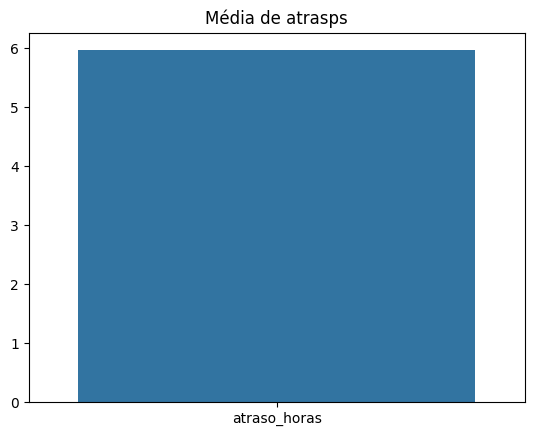

In [15]:
media = df["atraso_horas"].mean()

sns.barplot(
    x=["atraso_horas"],
    y=[media]
)

plt.title("Média de atrasps")
plt.show()

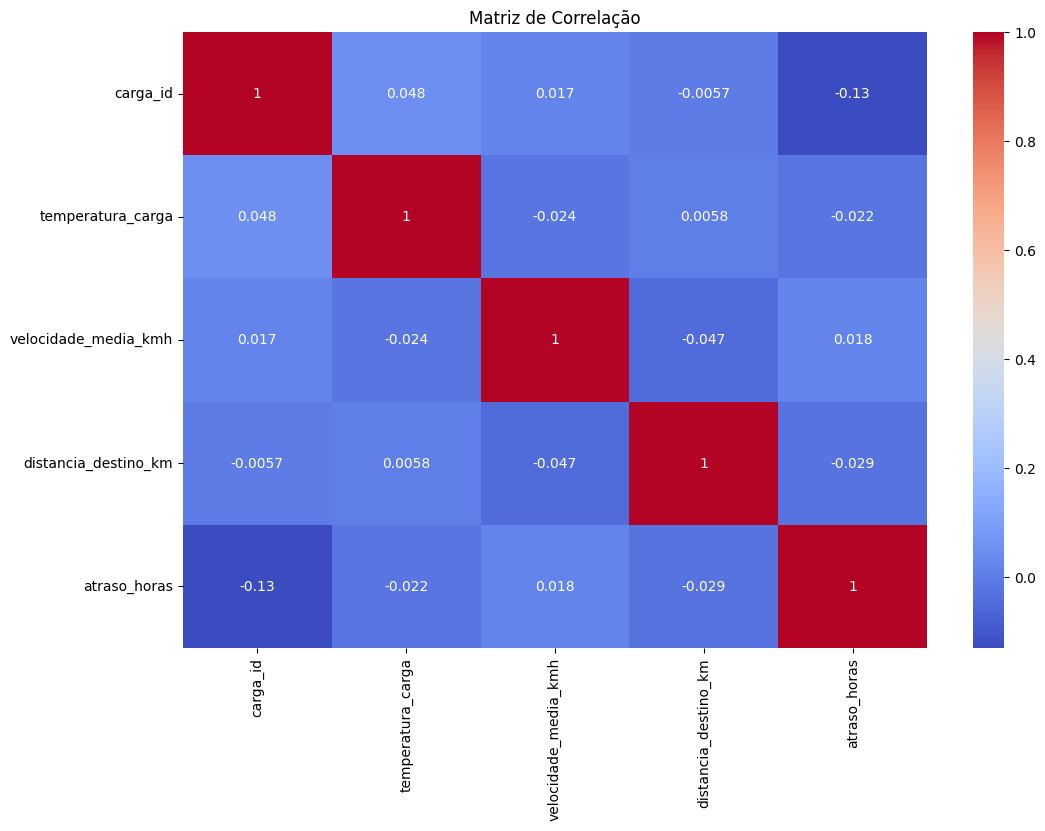

In [9]:
 #Correlação entre as features numéricas
numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
#aqui na parte de cima faz considerar como numéricas todas as colunas que sejam inteiras ou decimais
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=numerics).corr(), annot=True, cmap='coolwarm')
plt.title("Matriz de Correlação")
plt.show()

A matriz de correlação foi utilizada para avaliar o grau de relacionamento linear entre as variáveis numéricas da base de dados. Os valores de correlação observados estão muito próximos de zero, indicando que não existem relações lineares fortes entre as variáveis analisadas. A maior correlação identificada foi entre carga_id e atraso_horas (-0,13), porém esse valor ainda é considerado muito fraco e sem relevância prática para a análise. As variáveis temperatura_carga, velocidade_media_kmh, distancia_destino_km e atraso_horas apresentaram correlações extremamente baixas entre si, sugerindo que cada atributo contribui de forma independente para a caracterização das cargas monitoradas. A ausência de correlações elevadas também reduz o risco de multicolinearidade, o que é positivo para o treinamento dos modelos de Machine Learning.

# TREINAMENTO DO MODELO
aqui nessa etapa preparamos a fase de treinamento do modelo separando as features e labels para leitura da machine learning


In [7]:
# Separando features e labels
X = df.drop (columns= ["risco","carga_id"])
y = df['risco']

# Label Encoder para a variável alvo
le = LabelEncoder()
y = le.fit_transform(y)

# Lista de colunas categóricas e aplicação de One-Hot Encoding
categorical_cols = ['status_rota', 'sinal_satelite','tipo_carga']
ohe = OneHotEncoder(handle_unknown='ignore')
X_encoded = pd.DataFrame(ohe.fit_transform(X[categorical_cols]).toarray())
X_encoded = X_encoded.add_prefix('OHE_')

# Removendo colunas categóricas originais
X = X.drop(categorical_cols, axis=1)

# Concatenando features numéricas + categóricas codificadas
X = pd.concat([X, X_encoded], axis=1)

# Dividindo treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Normalização
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
# Random Forest
rf = RandomForestClassifier(n_estimators=25)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
print("Acurácia Random Forest:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Acurácia Random Forest: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        74
           1       1.00      1.00      1.00         5
           2       1.00      1.00      1.00        21

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



In [9]:
#regressão logistica
logreg = LogisticRegression()
logreg.fit(X_train_scaled, y_train)

y_pred_logreg = logreg.predict(X_test_scaled)

print("Acurácia Regressão Logística:", accuracy_score(y_test, y_pred_logreg))
print(classification_report(y_test, y_pred_logreg))

#KNN

knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("Acurácia KNN:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

Acurácia Regressão Logística: 0.93
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        74
           1       1.00      0.20      0.33         5
           2       0.82      0.86      0.84        21

    accuracy                           0.93       100
   macro avg       0.93      0.69      0.72       100
weighted avg       0.93      0.93      0.92       100

Acurácia KNN: 0.83
              precision    recall  f1-score   support

           0       0.90      0.88      0.89        74
           1       1.00      0.40      0.57         5
           2       0.62      0.76      0.68        21

    accuracy                           0.83       100
   macro avg       0.84      0.68      0.71       100
weighted avg       0.85      0.83      0.83       100



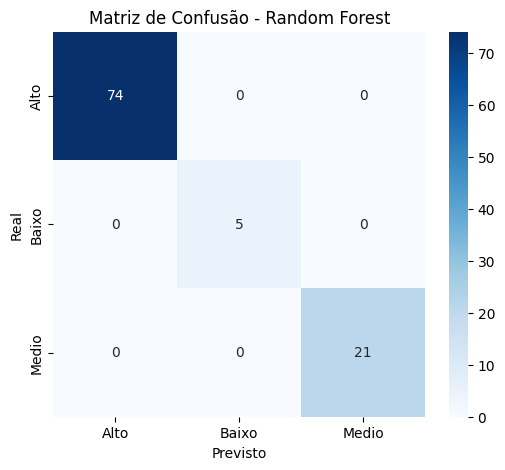

In [10]:
# Criando matriz de confusão
cm = confusion_matrix(y_test, y_pred_rf)

# Plotando heatmap
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Random Forest")
plt.show()


O modelo escolhido foi o random forest por conta da sua melhor adaptação nos testes, foram treinados mais 2 modelos (regressão logistica e knn) para enter se o modelo estava realmente bem treinado, se ele tinha se apegado a padrões para a previsão do risco ou se haviam outros modelos que se adaptariam melhor, Além da matriz de confusão que foi usado para avaliar a acertividade do modelo

# DASHBOARD

In [ ]:

#DASHBOARD
st.title("SatLog Tracker — Monitoramento de Cargas por Satélite")
st.write("sistema que analisa dados de GPS, satélite e sensores para prever o risco logístico das cargas.")

total_cargas = df["carga_id"].nunique()
cargas_risco_alto = df[df["risco"] == "Alto"].shape[0]
media_atraso = df["atraso_horas"].mean()
temperatura_media = df["temperatura_carga"].mean()

col1, col2, col3, col4 = st.columns(4)

col1.metric("Cargas monitorados", total_cargas)
col2.metric("Cargas com risco alto", cargas_risco_alto)
col3.metric("Media de atraso",f"{media_atraso:.1f}H")
col4.metric("Temperatura Média das carga", f"{temperatura_media:.1f}C")

st.sidebar.header("Filtros")

filtro_carga = st.sidebar.multiselect(
    "Tipo de Carga",
    df["tipo_carga"].unique(),
    default=df["tipo_carga"].unique()
)

filtro_risco = st.sidebar.multiselect(
    "Risco",
    df["risco"].unique(),
    default=df["risco"].unique()
)

filtro_status = st.sidebar.multiselect(
    "status da rota",
    df["status_rota"].unique(),
    default=df["status_rota"].unique())

filtro_sinal = st.sidebar.multiselect(
    "sinal de satelite",
    df["sinal_satelite"].unique(),
    default=df["sinal_satelite"].unique()
)
df_filtrado = df[
    (df["tipo_carga"].isin(filtro_carga)) &
    (df["risco"].isin(filtro_risco)) &
    (df["status_rota"].isin(filtro_status)) &
    (df["sinal_satelite"].isin(filtro_sinal))]

import plotly.express as px

# =========================
# GRÁFICO 1 - RISCO
# =========================

fig = px.histogram(
    df_filtrado,
    x="risco",
    color="risco",
    title="Quantidade de Cargas por Nível de Risco",
    text_auto=True
)

fig.update_layout(
    xaxis_title="Nível de Risco",
    yaxis_title="Quantidade de Cargas",
    template="plotly_white"
)

st.plotly_chart(fig, use_container_width=True)

# =========================
# GRÁFICO 2 - TIPO DE CARGA
# =========================

fig = px.histogram(
    df_filtrado,
    x="tipo_carga",
    color="risco",
    barmode="group",
    title="Distribuição de Risco por Tipo de Carga",
    text_auto=True
)

fig.update_layout(
    xaxis_title="Tipo de Carga",
    yaxis_title="Quantidade",
    template="plotly_white"
)

st.plotly_chart(fig, use_container_width=True)

# =========================
# GRÁFICO 3 - ATRASO MÉDIO
# =========================

atraso_medio = (
    df_filtrado
    .groupby("risco", as_index=False)["atraso_horas"]
    .mean()
)

fig = px.bar(
    atraso_medio,
    x="risco",
    y="atraso_horas",
    color="risco",
    title="Atraso Médio por Nível de Risco",
    text="atraso_horas"
)

fig.update_traces(
    texttemplate="%{text:.2f}h",
    textposition="outside"
)

fig.update_layout(
    xaxis_title="Nível de Risco",
    yaxis_title="Atraso Médio (Horas)",
    template="plotly_white"
)

st.plotly_chart(fig, use_container_width=True)

df_dash = df.drop(columns=["temperatura_carga","velocidade_media_kmh","distancia_destino_km"])
st.title("DADOS DAS CARGAS")
st.write(df_dash)

st.title("PREVER DADOS DE RISCO")
st.write("insira dados para que nossa machine learning treinada possa prever o seu risco")
temperatura_carga = st.number_input("Temperatura da carga")
velocidade_media_kmh = st.number_input("velocidade media em KMH")
distancia_destino_km = st.number_input("Distancia do Destino em Km")
atraso_horas = st.number_input("Atraso em horas")
status_rota = st.selectbox(
    "status da rota",
    ["Parado", "Desvio", "Normal"])
sinal_satelite = st.selectbox(
    "Sinal do satelite",
    ["Medio","Fraco","Forte"])
tipo_carga = st.selectbox(
    "tipo da carga",
    ["Medicamento","eletronico","Alimento"])

if st.button("Prever"):

    dados_numericos = pd.DataFrame({
        "temperatura_carga": [temperatura_carga],
        "velocidade_media_kmh": [velocidade_media_kmh],
        "distancia_destino_km": [distancia_destino_km],
        "atraso_horas": [atraso_horas]
    })

    dados_categoricos = pd.DataFrame({
        "status_rota": [status_rota],
        "sinal_satelite": [sinal_satelite],
        "tipo_carga": [tipo_carga]
    })

    dados_ohe = ohe.transform(dados_categoricos).toarray()

    dados_ohe_df = pd.DataFrame(
        dados_ohe,
        columns=[f"OHE_{i}" for i in range(dados_ohe.shape[1])]
    )
    input_df = pd.concat(
        [dados_numericos, dados_ohe_df],
        axis=1
    )

    input_scaled = scaler.transform(input_df)

    pred = rf.predict(input_scaled)

    resultado = le.inverse_transform(pred)

    if resultado[0] == "Alto":
        st.error("Risco Alto")
    elif resultado[0] == "Medio":
        st.warning("Risco Médio")
    else:
        st.success("Risco Baixo")

